In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics as stats

In [2]:
df = pd.read_csv("C:\\Users\\sathv\\Downloads\\deputies_dataset.csv\\deputies_dataset.csv")

In [3]:
df.head(10)

,bugged_date,receipt_date,deputy_id,political_party,state_code,deputy_name,receipt_social_security_number,receipt_description,establishment_name,receipt_value
0,0,2013-03-27 00:00:00,1772,PSB,SP,Abelardo Camarinha,3.530749e+12,Fuels and lubricants.,AUTO POSTO 314 NORTE LTDA,70
1,0,2013-07-24 00:00:00,1772,PSB,SP,Abelardo Camarinha,8.202116e+12,Fuels and lubricants.,AUTO POSTO AEROPORTO LTDA,104
2,0,2013-02-17 00:00:00,1772,PSB,SP,Abelardo Camarinha,8.202116e+12,Fuels and lubricants.,AUTO POSTO AEROPORTO LTDA,100
3,0,2013-03-15 00:00:00,1772,PSB,SP,Abelardo Camarinha,8.202116e+12,Fuels and lubricants.,AUTO POSTO AEROPORTO LTDA,100
4,0,2013-01-27 00:00:00,1772,PSB,SP,Abelardo Camarinha,8.202116e+12,Fuels and lubricants.,AUTO POSTO AEROPORTO LTDA,77
5,0,2013-02-06 00:00:00,1772,PSB,SP,Abelardo Camarinha,8.202116e+12,Fuels and lubricants.,AUTO POSTO AEROPORTO LTDA,131
6,0,2013-04-18 00:00:00,1772,PSB,SP,Abelardo Camarinha,6.143204e+12,Fuels and lubricants.,AUTO POSTO AV ESMERALDA LTDA,2840
7,0,2013-05-14 00:00:00,1772,PSB,SP,Abelardo Camarinha,6.143204e+12,Fuels and lubricants.,AUTO POSTO AV ESMERALDA LTDA,2517
8,0,2013-06-21 00:00:00,1772,PSB,SP,Abelardo Camarinha,6.143204e+12,Fuels and lubricants.,AUTO POSTO AV ESMERALDA LTDA,2509
9,0,2013-07-20 00:00:00,1772,PSB,SP,Abelardo Camarinha,6.143204e+12,Fuels and lubricants.,AUTO POSTO AV ESMERALDA LTDA,2720


In [4]:
df.describe()

,bugged_date,deputy_id,receipt_social_security_number,receipt_value
count,3.014902e+06,3.014902e+06,2.493950e+06,3.014902e+06
mean,1.642873e-02,1.869101e+03,1.372664e+13,5.791575e+02
std,1.271174e-01,7.014751e+02,2.057245e+13,1.925418e+03
min,0.000000e+00,1.200000e+01,0.000000e+00,0.000000e+00
25%,0.000000e+00,1.467000e+03,2.087236e+12,5.000000e+01
50%,0.000000e+00,1.882000e+03,7.423935e+12,1.420000e+02
75%,0.000000e+00,2.340000e+03,1.123836e+13,4.720000e+02
max,1.000000e+00,3.173000e+03,9.874986e+13,2.150000e+05


In [5]:
type(df)

pandas.core.frame.DataFrame

In [7]:
# function to detect outliers
def find_anomalies(df):
    # here find_anomalies is a function name.it takes data as input and returns a list of anomalies.
    #define a list to accumlate anomalies
    anomalies = []
    #set upper and lower limit to 3 standard deviation
    random_data_std = stats.stdev(df)
    random_data_mean = stats.mean(df)
    # 3-standard deviation
    anomaly_cut_off = random_data_std * 3
    lower_limit  = random_data_mean - anomaly_cut_off
    upper_limit = random_data_mean + anomaly_cut_off
    #generate outliers
    for outlier in df:
        if outlier > upper_limit or outlier < lower_limit:
            anomalies.append(outlier)                       
    return anomalies

In [8]:
df.columns

Index(['bugged_date', 'receipt_date', 'deputy_id', 'political_party',
       'state_code', 'deputy_name', 'receipt_social_security_number',
       'receipt_description', 'establishment_name', 'receipt_value'],
      dtype='object')

<Axes: >

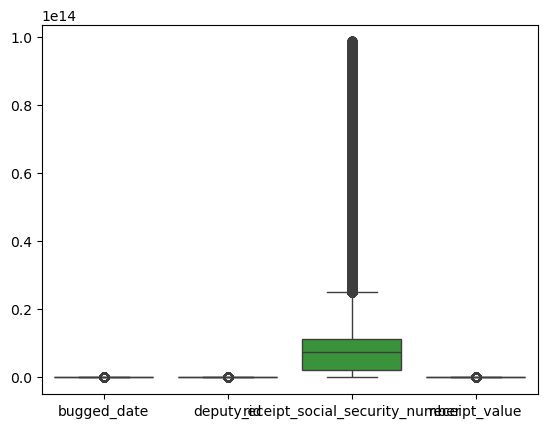

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df)

In [14]:
df.receipt_value.describe()

count    3.014902e+06
mean     5.791575e+02
std      1.925418e+03
min      0.000000e+00
25%      5.000000e+01
50%      1.420000e+02
75%      4.720000e+02
max      2.150000e+05
Name: receipt_value, dtype: float64

In [15]:
df.receipt_value

0           70
1          104
2          100
3          100
4           77
          ... 
3014897    993
3014898    588
3014899    773
3014900    508
3014901    528
Name: receipt_value, Length: 3014902, dtype: int64

In [16]:
list = find_anomalies(df['receipt_value'])

In [17]:
len(list)

39294

we have 39294 outliers.

In [18]:
len(df)

3014902

39294/3014902*100 = 1.3033%

In [19]:
df.receipt_value.skew()

np.float64(18.66101851290043)

In [20]:
float(df.receipt_value.skew())

18.66101851290043

the receipt_value is positively skewed

In [21]:
import seaborn as sns

<Axes: xlabel='receipt_value', ylabel='Density'>

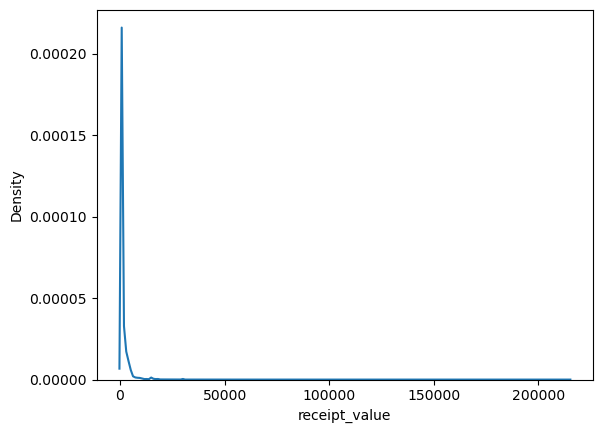

In [22]:
sns.kdeplot(df.receipt_value)

In [23]:
df["receipt_value_transformed"] = np.log(df.receipt_value)

c:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


might be the data is having some nan in it lets check and clear all the null values

In [24]:
df.head(20)

,bugged_date,receipt_date,deputy_id,political_party,state_code,deputy_name,receipt_social_security_number,receipt_description,establishment_name,receipt_value,receipt_value_transformed
0,0,2013-03-27 00:00:00,1772,PSB,SP,Abelardo Camarinha,3.530749e+12,Fuels and lubricants.,AUTO POSTO 314 NORTE LTDA,70,4.248495
1,0,2013-07-24 00:00:00,1772,PSB,SP,Abelardo Camarinha,8.202116e+12,Fuels and lubricants.,AUTO POSTO AEROPORTO LTDA,104,4.644391
2,0,2013-02-17 00:00:00,1772,PSB,SP,Abelardo Camarinha,8.202116e+12,Fuels and lubricants.,AUTO POSTO AEROPORTO LTDA,100,4.605170
3,0,2013-03-15 00:00:00,1772,PSB,SP,Abelardo Camarinha,8.202116e+12,Fuels and lubricants.,AUTO POSTO AEROPORTO LTDA,100,4.605170
4,0,2013-01-27 00:00:00,1772,PSB,SP,Abelardo Camarinha,8.202116e+12,Fuels and lubricants.,AUTO POSTO AEROPORTO LTDA,77,4.343805
5,0,2013-02-06 00:00:00,1772,PSB,SP,Abelardo Camarinha,8.202116e+12,Fuels and lubricants.,AUTO POSTO AEROPORTO LTDA,131,4.875197
6,0,2013-04-18 00:00:00,1772,PSB,SP,Abelardo Camarinha,6.143204e+12,Fuels and lubricants.,AUTO POSTO AV ESMERALDA LTDA,2840,7.951559
7,0,2013-05-14 00:00:00,1772,PSB,SP,Abelardo Camarinha,6.143204e+12,Fuels and lubricants.,AUTO POSTO AV ESMERALDA LTDA,2517,7.830823
8,0,2013-06-21 00:00:00,1772,PSB,SP,Abelardo Camarinha,6.143204e+12,Fuels and lubricants.,AUTO POSTO AV ESMERALDA LTDA,2509,7.827640
9,0,2013-07-20 00:00:00,1772,PSB,SP,Abelardo Camarinha,6.143204e+12,Fuels and lubricants.,AUTO POSTO AV ESMERALDA LTDA,2720,7.908387


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3014902 entries, 0 to 3014901
Data columns (total 11 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   bugged_date                     int64  
 1   receipt_date                    object 
 2   deputy_id                       int64  
 3   political_party                 object 
 4   state_code                      object 
 5   deputy_name                     object 
 6   receipt_social_security_number  float64
 7   receipt_description             object 
 8   establishment_name              object 
 9   receipt_value                   int64  
 10  receipt_value_transformed       float64
dtypes: float64(2), int64(3), object(6)
memory usage: 253.0+ MB


In [26]:
df.isnull().sum()

bugged_date                            0
receipt_date                           0
deputy_id                              0
political_party                        0
state_code                             0
deputy_name                            0
receipt_social_security_number    520952
receipt_description                    0
establishment_name                     0
receipt_value                          0
receipt_value_transformed              0
dtype: int64

In [27]:
df["receipt_value"].dtype

dtype('int64')

In [28]:
df["receipt_value_transformed"] = np.log(df.receipt_value)

c:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [28]:
df['receipt_value_transformed'] = np.log(df['receipt_value'] + 1)


In [29]:
df.receipt_value_transformed.skew()

np.float64(-0.04726426025861703)

In [30]:
float(df.receipt_value_transformed.skew())

-0.04726426025861703

In [31]:
list = find_anomalies(df.receipt_value_transformed)

In [32]:
len(list)

9252

In [33]:
len(df)

3014902

<Axes: xlabel='receipt_value_transformed', ylabel='Density'>

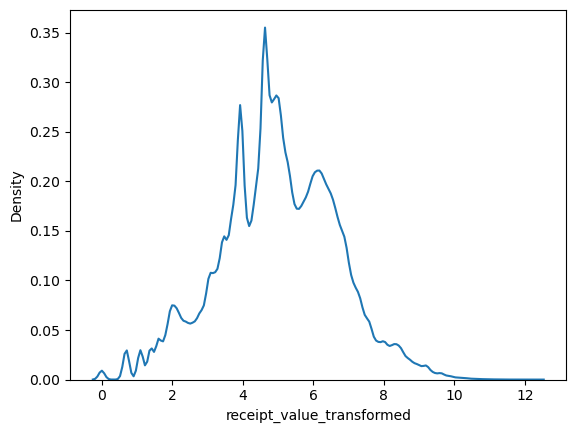

In [35]:
sns.kdeplot(df.receipt_value_transformed)

this is near to 0.30%

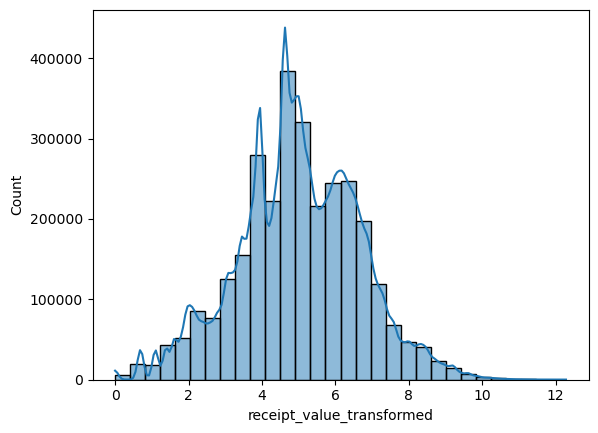

In [36]:
sns.histplot(df['receipt_value_transformed'], bins=30, kde=True)
plt.show()


<Axes: >

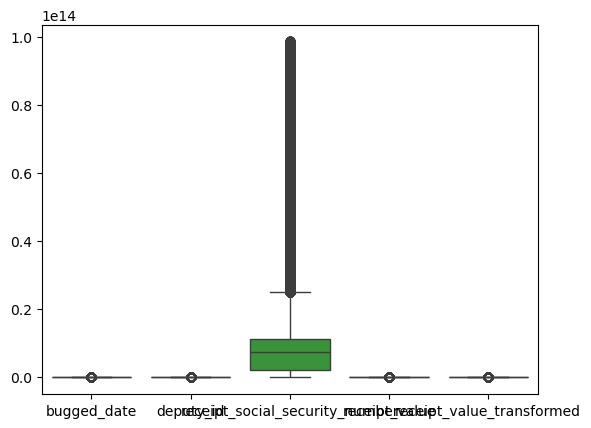

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df)

In [40]:
df.describe()

,bugged_date,deputy_id,receipt_social_security_number,receipt_value,receipt_value_transformed
count,3.014902e+06,3.014902e+06,2.493950e+06,3.014902e+06,3.014902e+06
mean,1.642873e-02,1.869101e+03,1.372664e+13,5.791575e+02,4.998107e+00
std,1.271174e-01,7.014751e+02,2.057245e+13,1.925418e+03,1.659854e+00
min,0.000000e+00,1.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,1.467000e+03,2.087236e+12,5.000000e+01,3.931826e+00
50%,0.000000e+00,1.882000e+03,7.423935e+12,1.420000e+02,4.962845e+00
75%,0.000000e+00,2.340000e+03,1.123836e+13,4.720000e+02,6.159095e+00
max,1.000000e+00,3.173000e+03,9.874986e+13,2.150000e+05,1.227840e+01


lets check outliers for receipt_social_security_number

In [41]:
df.isnull().sum()

bugged_date                            0
receipt_date                           0
deputy_id                              0
political_party                        0
state_code                             0
deputy_name                            0
receipt_social_security_number    520952
receipt_description                    0
establishment_name                     0
receipt_value                          0
receipt_value_transformed              0
dtype: int64

In [34]:
df['receipt_social_security_number'].head()


0    3.530749e+12
1    8.202116e+12
2    8.202116e+12
3    8.202116e+12
4    8.202116e+12
Name: receipt_social_security_number, dtype: float64

In [35]:
df['receipt_social_security_number'].isnull().sum()

np.int64(520952)

In [37]:
df['receipt_social_security_number'].describe()

count    2.493950e+06
mean     1.372664e+13
std      2.057245e+13
min      0.000000e+00
25%      2.087236e+12
50%      7.423935e+12
75%      1.123836e+13
max      9.874986e+13
Name: receipt_social_security_number, dtype: float64

In [38]:
df['receipt_social_security_number'].mean()
#updated_df1['Age'] = updated_df1['Age'].fillna(df['Age'].mean())

np.float64(13726644826123.592)

In [39]:
df['receipt_social_security_number']= df['receipt_social_security_number'].fillna(df['receipt_social_security_number'].mean())

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3014902 entries, 0 to 3014901
Data columns (total 11 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   bugged_date                     int64  
 1   receipt_date                    object 
 2   deputy_id                       int64  
 3   political_party                 object 
 4   state_code                      object 
 5   deputy_name                     object 
 6   receipt_social_security_number  float64
 7   receipt_description             object 
 8   establishment_name              object 
 9   receipt_value                   int64  
 10  receipt_value_transformed       float64
dtypes: float64(2), int64(3), object(6)
memory usage: 253.0+ MB


In [41]:
df.isnull().sum()

bugged_date                       0
receipt_date                      0
deputy_id                         0
political_party                   0
state_code                        0
deputy_name                       0
receipt_social_security_number    0
receipt_description               0
establishment_name                0
receipt_value                     0
receipt_value_transformed         0
dtype: int64

In [ ]:
#function to detect outliers
def find_anomalies(df):
    # here find_anomalies is a function name.it takes data as input and returns a list of anomalies.
    #define a list to accumlate anomalies
    anomalies = []
    #set upper and lower limit to 3 standard deviation
    random_data_std = stats.stdev(df)
    random_data_mean = stats.mean(df)
    # 3-standard deviation
    anomaly_cut_off = random_data_std * 3
    lower_limit  = random_data_mean - anomaly_cut_off
    upper_limit = random_data_mean + anomaly_cut_off
    #generate outliers
    for outlier in df:
        if outlier > upper_limit or outlier < lower_limit:
            anomalies.append(outlier)                       
    return anomalies

In [42]:
df['receipt_social_security_number'].describe()

count    3.014902e+06
mean     1.372664e+13
std      1.871084e+13
min      0.000000e+00
25%      2.558157e+12
50%      7.575651e+12
75%      1.372664e+13
max      9.874986e+13
Name: receipt_social_security_number, dtype: float64

In [43]:
list = find_anomalies(df['receipt_social_security_number'])

In [44]:
len(list)

128208

In [45]:
len(df)

3014902

it is nearly 4.25%

In [46]:
df['receipt_social_security_number'].skew()

np.float64(2.6119731792638556)

In [47]:
float(df['receipt_social_security_number'].skew())

2.6119731792638556

<Axes: xlabel='receipt_social_security_number', ylabel='Density'>

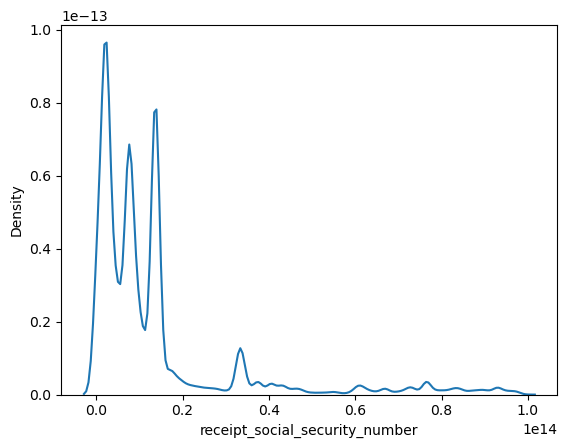

In [49]:
import seaborn as sns
sns.kdeplot(df['receipt_social_security_number'])
#sns.kdeplot(df['receipt_value'])

In [50]:
df['receipt_social_security_number_transformed'] = np.log(df['receipt_social_security_number'] + 1)

In [51]:
df['receipt_social_security_number_transformed'].skew()

np.float64(-1.7156714248508582)

In [52]:
float(df['receipt_social_security_number_transformed'].skew())

-1.7156714248508582

In [53]:
list_1 = find_anomalies(df['receipt_social_security_number_transformed'])

In [54]:
len(list_1)

83874

<Axes: xlabel='receipt_social_security_number_transformed', ylabel='Density'>

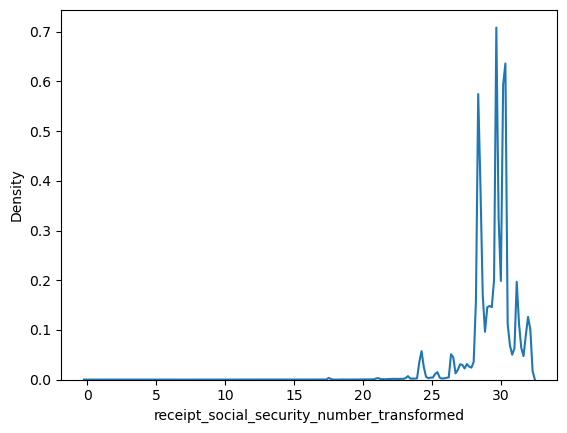

In [55]:
sns.kdeplot(df['receipt_social_security_number_transformed'])

In [56]:
df['receipt_social_security_number_doubletransformed'] = np.log(df['receipt_social_security_number'] + 1)

In [57]:
df['receipt_social_security_number_doubletransformed'].skew()

np.float64(-1.7156714248508582)

In [58]:
float(df['receipt_social_security_number_doubletransformed'].skew())

-1.7156714248508582

In [60]:
list_2 = find_anomalies(df['receipt_social_security_number_doubletransformed'])

In [61]:
len(list_2)

83874

<Axes: xlabel='receipt_social_security_number_doubletransformed', ylabel='Density'>

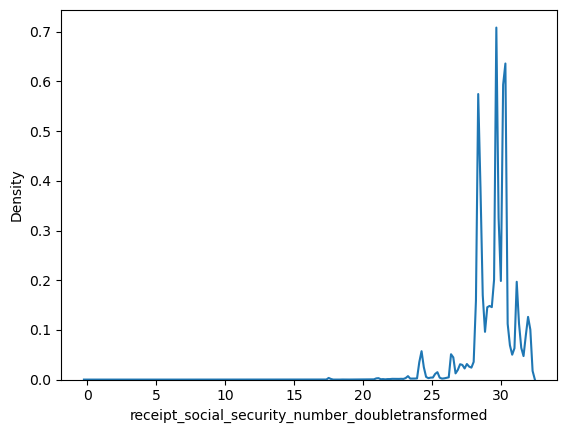

In [62]:
sns.kdeplot(df['receipt_social_security_number_doubletransformed'])

<Axes: >

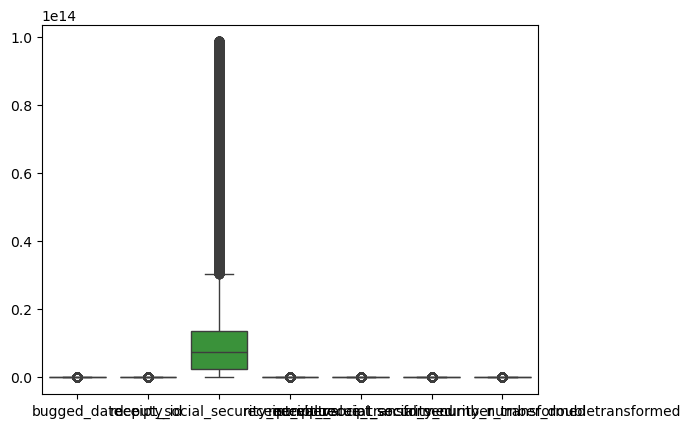

In [63]:
sns.boxplot(data=df)

<Axes: ylabel='receipt_social_security_number_doubletransformed'>

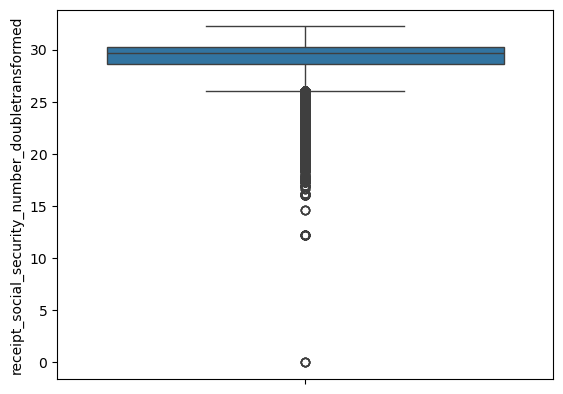

In [64]:
sns.boxplot(data=df['receipt_social_security_number_doubletransformed'])

<Axes: ylabel='receipt_social_security_number_transformed'>

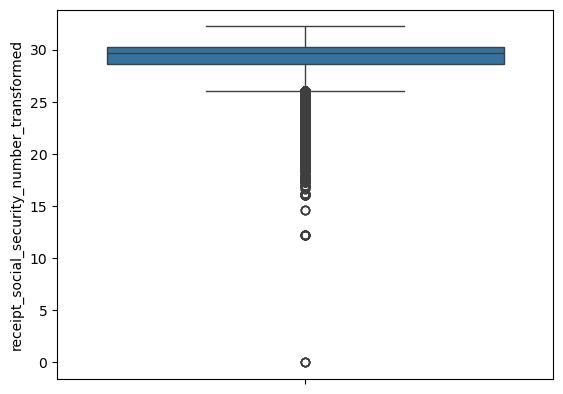

In [65]:
sns.boxplot(data=df['receipt_social_security_number_transformed'])

<Axes: ylabel='receipt_social_security_number_transformed'>

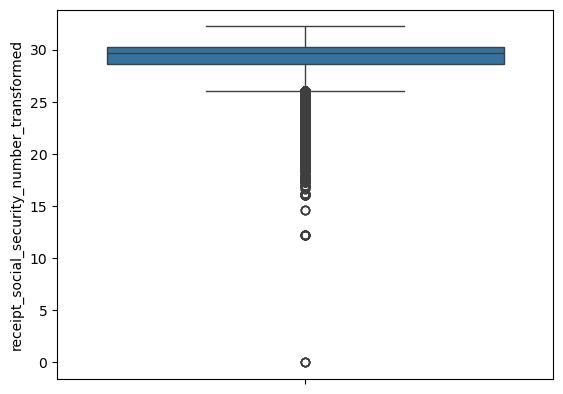

In [66]:
sns.boxplot(data=df['receipt_social_security_number_transformed'])